In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/kaggle/input/titanic/train.csv')

In [4]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [8]:
df['Age']=df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))

In [9]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [10]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [13]:
df.describe(include='all')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889,889.000000,889.000000,889.000000,889.000000,889
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644
mean,0.382452,2.311586,NaN,29.246290,0.524184,0.382452,32.096681,NaN
std,0.486260,0.834700,NaN,13.176451,1.103705,0.806761,49.697504,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.895800,NaN
50%,0.000000,3.000000,NaN,26.000000,0.000000,0.000000,14.454200,NaN
75%,1.000000,3.000000,NaN,36.500000,1.000000,0.000000,31.000000,NaN


In [14]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['Sex','Embarked']]=oe.fit_transform(df[['Sex','Embarked']])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1.0,22.0,1,0,7.2500,2.0
1,1,1,0.0,38.0,1,0,71.2833,0.0
2,1,3,0.0,26.0,0,0,7.9250,2.0
3,1,1,0.0,35.0,1,0,53.1000,2.0
4,0,3,1.0,35.0,0,0,8.0500,2.0


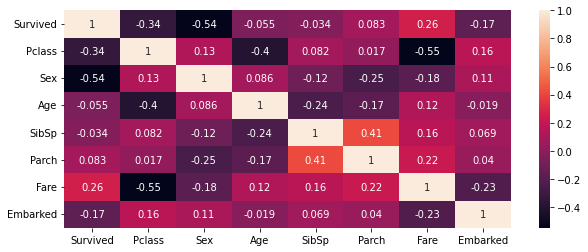

In [15]:
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [16]:
df['Family']=df['SibSp']+df['Parch']
df.drop(['SibSp','Parch'],axis=1,inplace=True)

In [17]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [18]:
y.value_counts()

0    549
1    340
Name: Survived, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=1,test_size=0.2,stratify=y)

In [20]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    acc=accuracy_score(ytest,ypred)
    cm=confusion_matrix(ytest,ypred)
    cr=classification_report(ytest,ypred)
    tr=model.score(xtrain,ytrain)
    te=model.score(xtest,ytest)
    print(str(model)[:-2],f'Accuracy: {acc}\n{cm}\n{cr}\nTraining Accuracy: {tr}\nTesting Accuracy: {te}')
    print()
    return model

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

knn=mymodel(KNeighborsClassifier())
lr=mymodel(LogisticRegression())
gnb=mymodel(GaussianNB())
svc=mymodel(SVC())
dt=mymodel(DecisionTreeClassifier(min_samples_leaf=1,max_depth=10))
c=mymodel(RandomForestClassifier())

KNeighborsClassifier Accuracy: 0.7415730337078652
[[87 23]
 [23 45]]
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       110
           1       0.66      0.66      0.66        68

    accuracy                           0.74       178
   macro avg       0.73      0.73      0.73       178
weighted avg       0.74      0.74      0.74       178

Training Accuracy: 0.7819971870604782
Testing Accuracy: 0.7415730337078652

LogisticRegression Accuracy: 0.8089887640449438
[[94 16]
 [18 50]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178

Training Accuracy: 0.8045007032348804
Testing Accuracy: 0.8089887640449438

GaussianNB Accuracy: 0.8089887640449438
[[93 17]
 [17 51]]

In [22]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [23]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x.iloc[:,:]=ss.fit_transform(x.iloc[:,:])

In [24]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=1,test_size=0.2,stratify=y)

In [25]:
knn=mymodel(KNeighborsClassifier())
lr=mymodel(LogisticRegression())
gnb=mymodel(GaussianNB())
svc=mymodel(SVC())
dt=mymodel(DecisionTreeClassifier())
rfc=mymodel(RandomForestClassifier(n_estimators=70,criterion='entropy',max_depth=15))

KNeighborsClassifier Accuracy: 0.8370786516853933
[[98 12]
 [17 51]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        68

    accuracy                           0.84       178
   macro avg       0.83      0.82      0.82       178
weighted avg       0.84      0.84      0.84       178

Training Accuracy: 0.8509142053445851
Testing Accuracy: 0.8370786516853933

LogisticRegression Accuracy: 0.8089887640449438
[[94 16]
 [18 50]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178

Training Accuracy: 0.8016877637130801
Testing Accuracy: 0.8089887640449438

GaussianNB Accuracy: 0.8089887640449438
[[93 17]
 [17 51]]

In [26]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x.iloc[:,:]=ss.fit_transform(x.iloc[:,:])

In [27]:
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler()
ros.fit_resample(x,y)
x.shape,y.shape


((889, 6), (889,))

In [28]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=2,test_size=0.25)

In [29]:
knn=mymodel(KNeighborsClassifier())
lr=mymodel(LogisticRegression())
gnb=mymodel(GaussianNB())
svc=mymodel(SVC())
dt=mymodel(DecisionTreeClassifier())
rfc=mymodel(RandomForestClassifier(n_estimators=70))

KNeighborsClassifier Accuracy: 0.852017937219731
[[131  12]
 [ 21  59]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       143
           1       0.83      0.74      0.78        80

    accuracy                           0.85       223
   macro avg       0.85      0.83      0.83       223
weighted avg       0.85      0.85      0.85       223

Training Accuracy: 0.8453453453453453
Testing Accuracy: 0.852017937219731

LogisticRegression Accuracy: 0.820627802690583
[[125  18]
 [ 22  58]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       143
           1       0.76      0.72      0.74        80

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.82      0.82      0.82       223

Training Accuracy: 0.8018018018018018
Testing Accuracy: 0.820627802690583

GaussianNB Accuracy: 0.7982062780269058
[[120  23]
 [ 

In [30]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

ada=mymodel(AdaBoostClassifier())
gb=mymodel(GradientBoostingClassifier())
xgb=mymodel(XGBClassifier(n_estimators=80))

AdaBoostClassifier Accuracy: 0.8116591928251121
[[121  22]
 [ 20  60]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       143
           1       0.73      0.75      0.74        80

    accuracy                           0.81       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223

Training Accuracy: 0.8243243243243243
Testing Accuracy: 0.8116591928251121

GradientBoostingClassifier Accuracy: 0.8565022421524664
[[131  12]
 [ 20  60]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       143
           1       0.83      0.75      0.79        80

    accuracy                           0.86       223
   macro avg       0.85      0.83      0.84       223
weighted avg       0.86      0.86      0.85       223

Training Accuracy: 0.9024024024024024
Testing Accuracy: 0.8565022421524664

XGBClassifier(base_score=0.5, booster='gbtre

In [31]:
xgb=XGBClassifier(n_estimators=80)
xgb.fit(xtrain,ytrain)
ypred=xgb.predict(xtest)
acc=accuracy_score(ytest,ypred)
cm=confusion_matrix(ytest,ypred)
cr=classification_report(ytest,ypred)
tr=xgb.score(xtrain,ytrain)
te=xgb.score(xtest,ytest)
print(f'Accuracy: {acc}\n{cm}\n{cr}\nTraining Accuracy: {tr}\nTesting Accuracy: {te}')

Accuracy: 0.8295964125560538
[[123  20]
 [ 18  62]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       143
           1       0.76      0.78      0.77        80

    accuracy                           0.83       223
   macro avg       0.81      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223

Training Accuracy: 0.9654654654654654
Testing Accuracy: 0.8295964125560538


In [32]:
ypred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1])

In [33]:
xtest

,Pclass,Sex,Age,Fare,Embarked,Family
560,0.825209,0.735342,-0.311767,-0.490173,-0.676357,-0.561804
37,0.825209,0.735342,-0.626188,-0.484133,0.586840,-0.561804
615,-0.373501,-1.359911,-0.398381,0.662445,0.586840,1.297169
170,-1.572211,0.735342,2.411240,0.028253,0.586840,-0.561804
69,0.825209,0.735342,-0.246509,-0.471802,0.586840,0.677511
...,...,...,...,...,...,...
274,0.825209,-1.359911,-0.311767,-0.490173,-0.676357,-0.561804
699,0.825209,0.735342,0.968462,-0.492187,0.586840,-0.561804
631,0.825209,0.735342,1.651883,-0.504182,0.586840,-0.561804
609,-1.572211,-1.359911,0.816590,2.443465,0.586840,-0.561804


# KNN and SVC is giving the best accuracy with least False Negative errors

In [34]:
df=pd.read_csv('/kaggle/input/titanic/test.csv')

In [35]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [36]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [37]:
df.isnull().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [38]:
df['Age']=df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


In [40]:
df['Fare'].fillna(df['Fare'].mean(),inplace=True)

In [41]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['Sex','Embarked']]=oe.fit_transform(df[['Sex','Embarked']])
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1.0,34.5,0,0,7.8292,1.0
1,3,0.0,47.0,1,0,7.0000,2.0
2,2,1.0,62.0,0,0,9.6875,1.0
3,3,1.0,27.0,0,0,8.6625,2.0
4,3,0.0,22.0,1,1,12.2875,2.0


In [42]:
df['Family']=df['SibSp']+df['Parch']
df.drop(['SibSp','Parch'],axis=1,inplace=True)

In [43]:
df

,Pclass,Sex,Age,Fare,Embarked,Family
0,3,1.0,34.500000,7.8292,1.0,0
1,3,0.0,47.000000,7.0000,2.0,1
2,2,1.0,62.000000,9.6875,1.0,0
3,3,1.0,27.000000,8.6625,2.0,0
4,3,0.0,22.000000,12.2875,2.0,2
...,...,...,...,...,...,...
413,3,1.0,24.027945,8.0500,2.0,0
414,1,0.0,39.000000,108.9000,0.0,0
415,3,1.0,38.500000,7.2500,2.0,0
416,3,1.0,24.027945,8.0500,2.0,0


In [44]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df.iloc[:,:]=ss.fit_transform(df.iloc[:,:])
df

,Pclass,Sex,Age,Fare,Embarked,Family
0,0.873482,0.755929,0.393201,-0.498407,-0.470915,-0.553443
1,0.873482,-1.322876,1.358498,-0.513274,0.700767,0.105643
2,-0.315819,0.755929,2.516855,-0.465088,-0.470915,-0.553443
3,0.873482,0.755929,-0.185977,-0.483466,0.700767,-0.553443
4,0.873482,-1.322876,-0.572096,-0.418471,0.700767,0.764728
...,...,...,...,...,...,...
413,0.873482,0.755929,-0.415491,-0.494448,0.700767,-0.553443
414,-1.505120,-1.322876,0.740708,1.313753,-1.642598,-0.553443
415,0.873482,0.755929,0.702096,-0.508792,0.700767,-0.553443
416,0.873482,0.755929,-0.415491,-0.494448,0.700767,-0.553443


In [45]:
pred=xgb.predict(df)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [46]:
test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [47]:
submission=pd.DataFrame({'PassengerId':test['PassengerId'],'Survived':pred})

In [48]:
filename='Titanic Prediction-XGBooster Model'
submission.to_csv(filename,index=False)

print('Saved File: '+filename)

Saved File: Titanic Prediction-XGBooster Model
